# Consignes

Cet énoncé vous est destiné à tous les trois. Les deux problèmes qu'il comporte sont entièrement construits à partir des TP réalisés ensemble. Les deux exercices sont des classiques.
Vous avez, comme déjà dit, droit à toute la matière que vous souhaitez (chatbots, notes personnelles, corrigés des TPs). \
À la fin de l'examen, vous enverrez à l'adresse tpdeeplearning@gmail.com une archive .tar contenant un notebook par problème et par exercice (soit quatre notebooks au maximum).

Vous serez évalués sur les points suivants:

- La rédaction.\
Présentez votre approche. En particulier, si vous utilisez un chatbot (ce que je recommande), vous pouvez simplement copier les prompts que vous utilisez dans des cellules du notebook tout en mettant en avant votre esprit critique (par exemple, en commentant les réponses fournies par la machine). Dans tous les cas, notez que c'est la qualité de votre production qui sera jugée avant tout. Il n'est donc pas primordial d'avoir été jusqu'au bout de l'énoncé.

- La propreté des notebooks.\
Ils doivent être organisés et faciles à lire. Je dois pouvoir faire tourner le code sans problème et en comprendre les éléments. Il faut donc commenter un minimum.


# Problème n°1 (1h)

Dans ce problème, il s'agit de tester une parade à l'imperfection des résultats au TP n°5, partie 2.

- Refaire tourner le code solution du TP°5 (avec deux échantillons de bruit noise et noise2 additionnels) en stockant les poids du réseau au bout de 40 époques.

- Pouvez-vous rappeler le défaut qui avait été observé dans la question 2 ?
  Ré-expliquez son origine en terme de médiane conditionnelle.

- Nous avons évoqué plusieurs parades. La première consiste simplement à ajouter un nouvel échantillon de bruit (noise3). Faites une expérience sur quarante époques. Procédez ensuite à une comparaison qualitative avec les sorties du  modèle précédent. Faites enfin une comparaison quantitative (limitée) à partir des images ne contenant que du bruit.

- Nous avons aussi évoqué la régression quantile. Pouvez-vous expliquer en quoi cette forme de régression est adaptée ? Faites une expérience sur quarante époque en visant le quantile d'ordre 0.4 (dans la configuration initiale, c'est à dire avec deux échantillons de bruit seulement). Le problème est-il parfaitement résolu ? Comme ci-dessus, vérifier de manière qualitative et quantitative.


Dans cet exercice nous avions 2 bruits à supprimer sur l'image d'origine et nous utilisions la MAE.
La MAE était une très bonne solution pour enlever un bruit sparse (-50% de recouvrement) mais ne fonctionne plus ici dèslors que deux rectangles bruités se chevauchent (overlap).
Dans le cas d'un overlap, la couleur de fond (de l'image d'origine) n'est plus majoritaire et la MAE (qui optimise vers la médiane) renvoie un pixel bruité.

Ajouter un 3ème bruit permet d'augmenter la probabilité d'overlap (qui était assez rare jusque là) dans l'idée qu'avec plus d'exemples le réseau apprendra mieux à les gérer.
Après 40 epochs on constate que les images sont parfaitement débruitées même sur les zones d'overlap.
En comparant les images qui ne contiennent que du bruit, on voit bien que la quasi totalité des images contient au moins un overlap

En modifiant la loss pour optimiser en direction d'un décile plus faible (ex 4ème décile) on force notre modèle à viser plus bas, c'est à dire que le modèle aura tendance à estimer du fond (pixel de valeurs 0) plus souvent et à mettre un pixel plus lumineux seulement lorsque sa certitude est plus grande.
Visuellement, ça résulte en un effet d'érosion lorsqu'un bruit chevauchait la bordure d'un cercle.

In [66]:
import torch
import matplotlib.pyplot as plt


! git clone https://github.com/nanopiero/ML_S5_etudiants
! cp ML_S5_etudiants/practicals/P5/utile.py .
from utile import gen1_NES, gen2_NES, voir_batch2D, UNet

fatal: destination path 'ML_S5_etudiants' already exists and is not an empty directory.


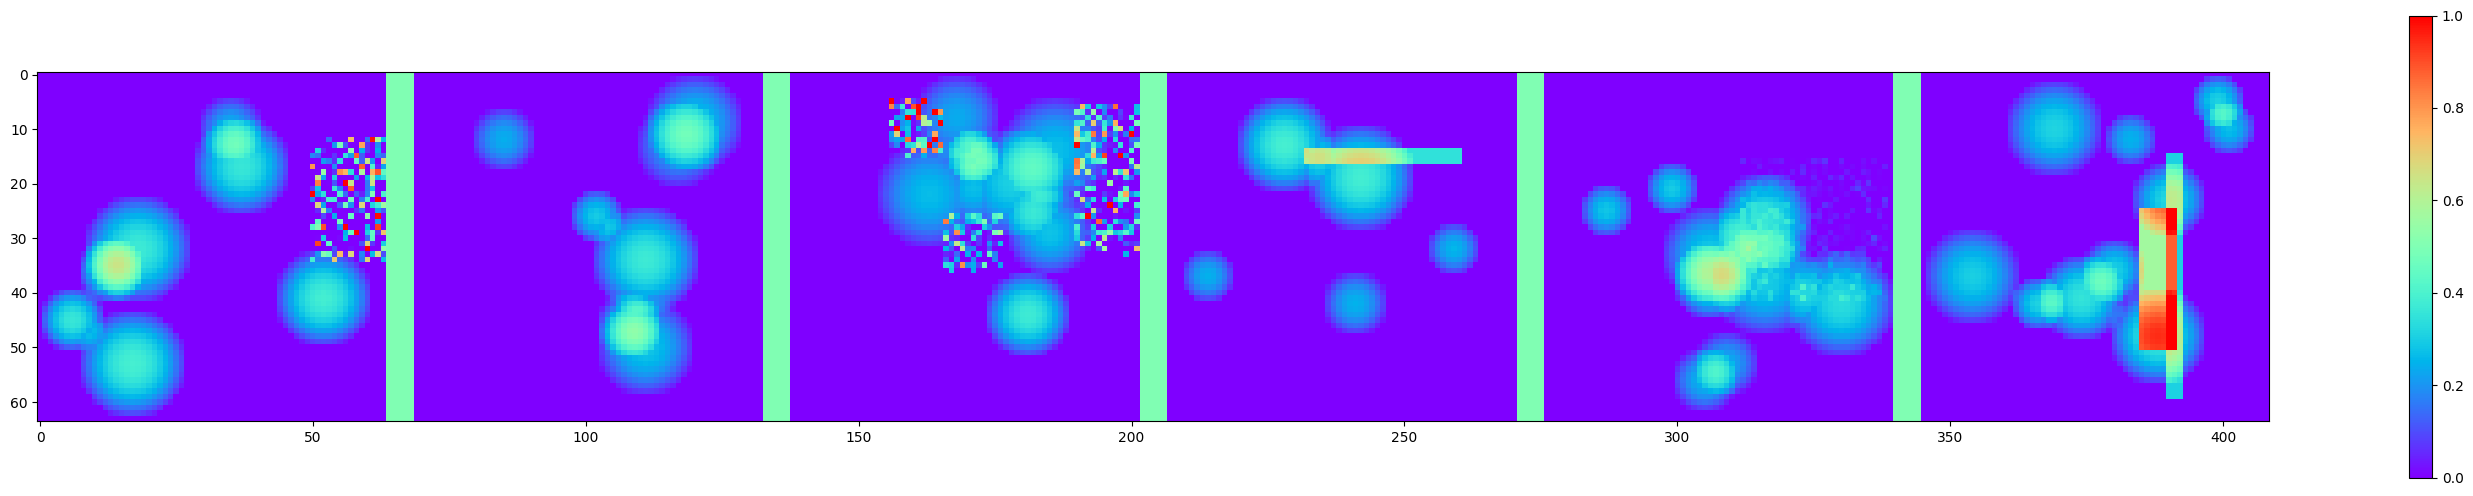

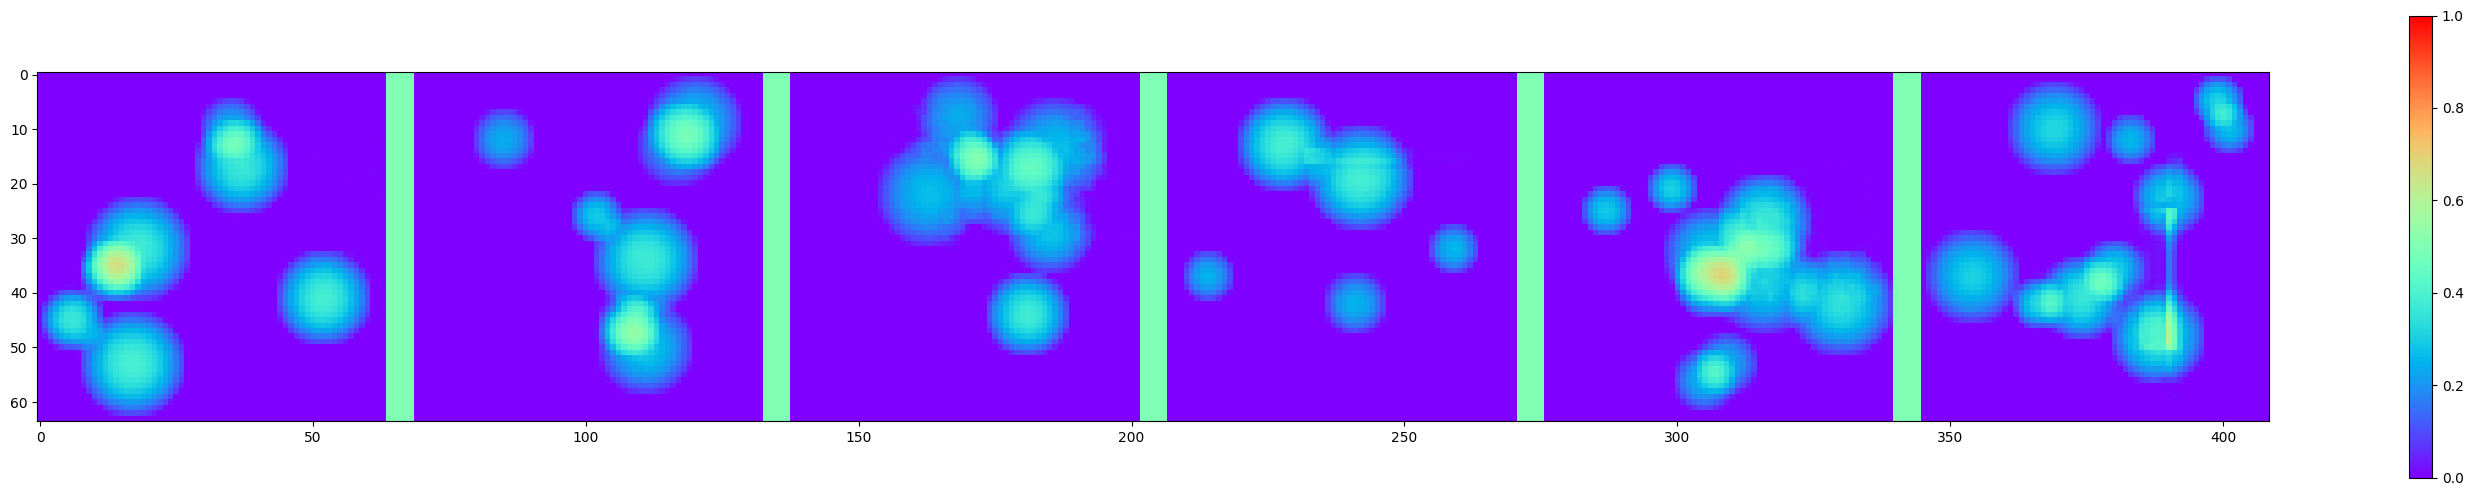

In [67]:
fcn = UNet(1,1,16).cuda()

model_path = 'fcn_weights_40_epochs.pth'

state_dict = torch.load(model_path)

fcn.load_state_dict(state_dict)

fcn.eval()

input = gen1_NES(6)
output = fcn(input.cuda())

fig = plt.figure(0, figsize=(36, 6))
voir_batch2D(input, 6, fig, k=0, min_scale=0,max_scale=1)

fig2 = plt.figure(2, figsize=(36, 6))
voir_batch2D(output.detach().cpu(), 6, fig2, k=0, min_scale=0,max_scale=1)


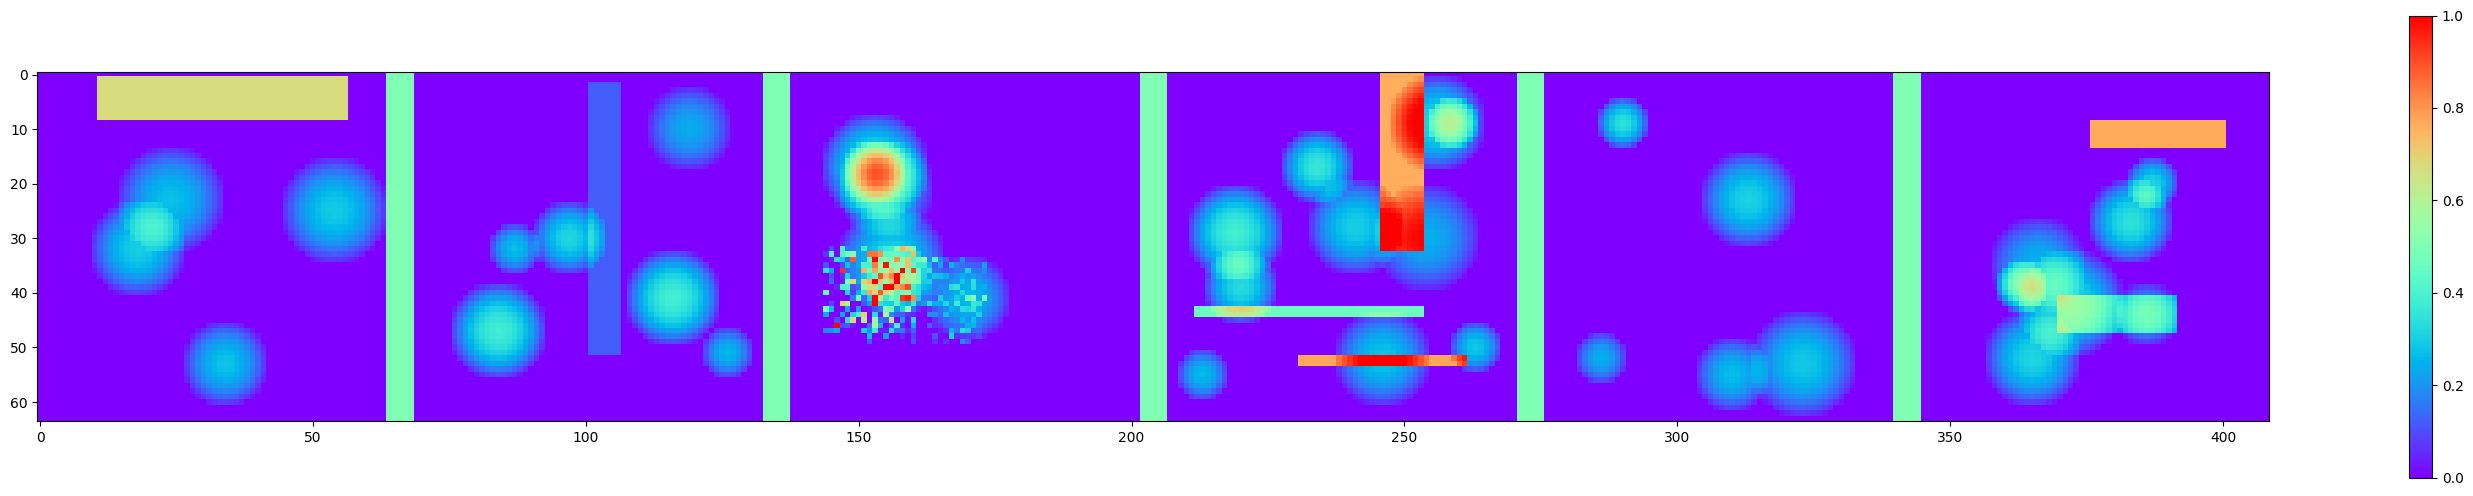

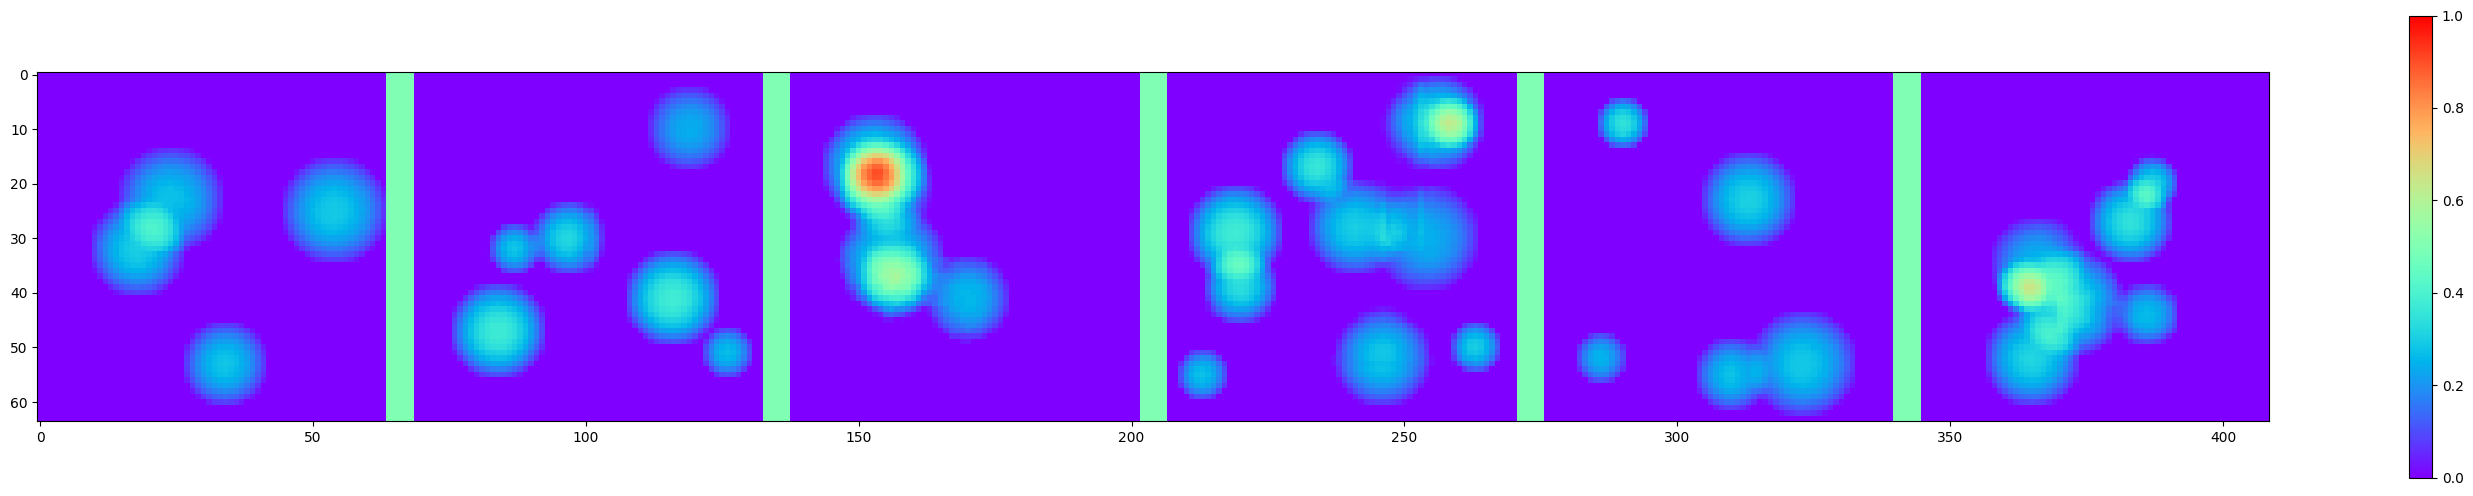

In [68]:
fcn = UNet(1,1,16).cuda()

model_path = 'fcn_weights_40_epochs_noise3.pth'

state_dict = torch.load(model_path)

fcn.load_state_dict(state_dict)

fcn.eval()

input = gen1_NES(6)
output = fcn(input.cuda())

fig = plt.figure(0, figsize=(36, 6))
voir_batch2D(input, 6, fig, k=0, min_scale=0,max_scale=1)

fig2 = plt.figure(2, figsize=(36, 6))
voir_batch2D(output.detach().cpu(), 6, fig2, k=0, min_scale=0,max_scale=1)


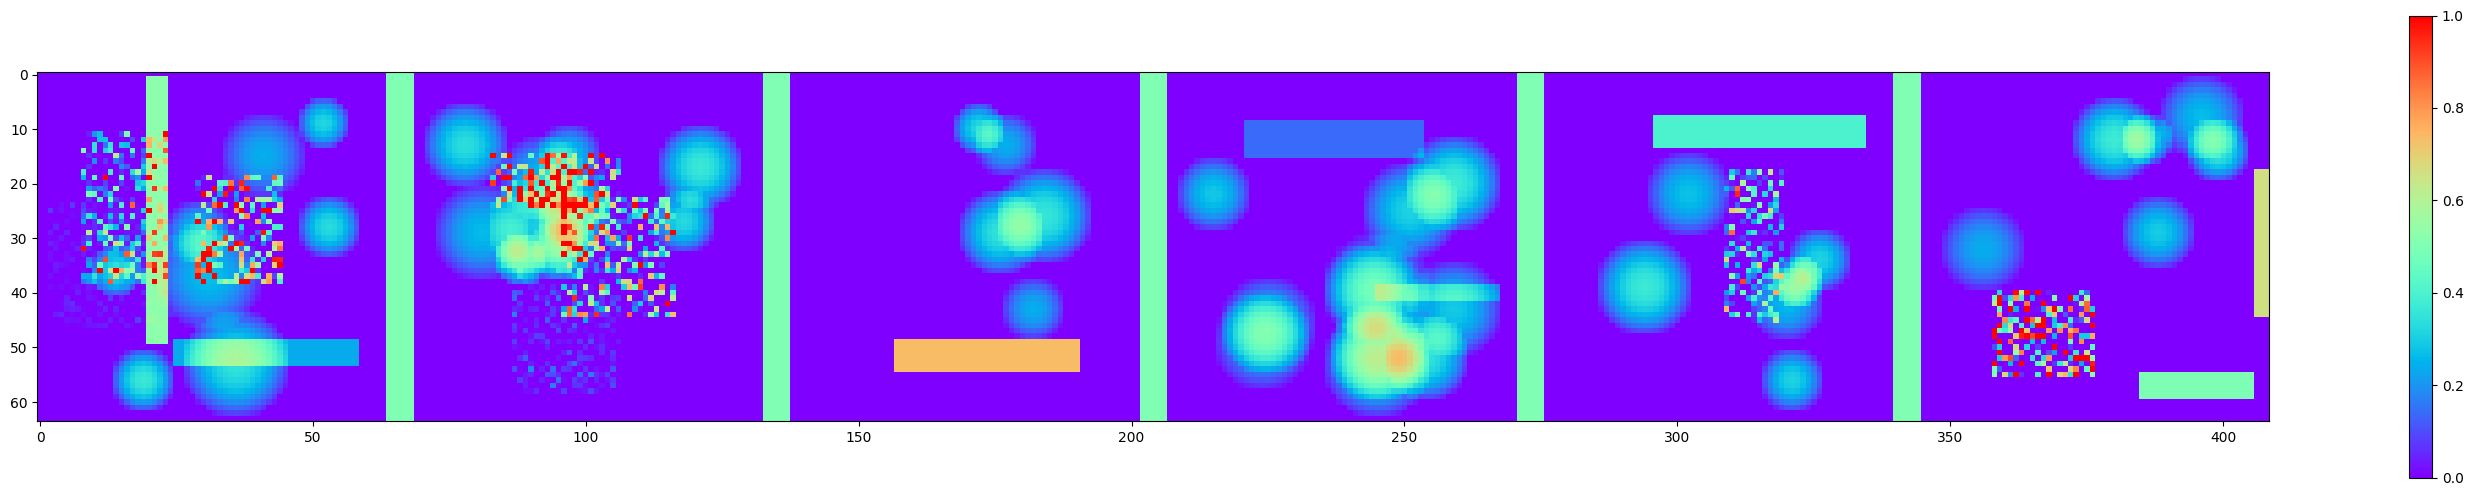

KeyboardInterrupt: 

In [69]:
fcn = UNet(1,1,16).cuda()

model_path = 'fcn_weights_40_epochs_decile4.pth'

state_dict = torch.load(model_path)

fcn.load_state_dict(state_dict)

fcn.eval()

input = gen1_NES(6)
output = fcn(input.cuda())

fig = plt.figure(0, figsize=(36, 6))
voir_batch2D(input, 6, fig, k=0, min_scale=0,max_scale=1)

fig2 = plt.figure(2, figsize=(36, 6))
voir_batch2D(output.detach().cpu(), 6, fig2, k=0, min_scale=0,max_scale=1)


# Problème n°2 (1h)

 Dans le TP n°4 sur les transformers, nous avons appris à un modèle à préciser la parité d'une suite de zéros et de uns. Vous devez :
- reprendre le transformer proposé et le faire converger sur des suites de taille 64.
- définir un CNN pour la classification binaire dont le champ réceptif est proche de 32 comportant trois couches de convolution et deux couches complètement connectées.
- comparer les courbes d'apprentissage du CNN et du transformer (finesse sur le jeu de validation)
- comparer le nombre de poids dans chacun des modèles
- conclure

## Setup

In [42]:
import math
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

In [43]:
device = "cuda:0"

In [44]:
# Tiny Transformer building blocks (embedding + multi-head attention)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 1024):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, L, D)
        L = x.size(1)
        return x + self.pe[:, :L, :]

class MultiHeadSelfAttention(nn.Module):
    """
    Minimal multi-head self-attention.
    If verbose=True, prints tensor shapes at key steps.
    """
    def __init__(self, d_model: int = 64, n_heads: int = 4, verbose: bool = False):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.verbose = verbose

        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)

    def _vprint(self, name, x):
        if self.verbose:
            print(f"{name}: {tuple(x.shape)}")

    def forward(self, x):
        # x: (B, L, D)
        B, L, D = x.shape

        Q = self.Wq(x)  # (B, L, D)
        K = self.Wk(x)
        V = self.Wv(x)
        self._vprint("Q", Q)
        self._vprint("K", K)
        self._vprint("V", V)

        # reshape to heads
        Q = Q.view(B, L, self.n_heads, self.d_head).transpose(1, 2)  # (B, H, L, Dh)
        K = K.view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        V = V.view(B, L, self.n_heads, self.d_head).transpose(1, 2)
        self._vprint("Q_heads", Q)
        self._vprint("K_heads", K)
        self._vprint("V_heads", V)

        # scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)  # (B,H,L,L)
        self._vprint("scores", scores)

        attn = torch.softmax(scores, dim=-1)  # (B,H,L,L)
        self._vprint("attn_probs", attn)

        Z = torch.matmul(attn, V)  # (B,H,L,Dh)
        self._vprint("Z_heads", Z)

        # merge heads
        Z = Z.transpose(1, 2).contiguous().view(B, L, D)  # (B, L, D)
        self._vprint("Z_merged", Z)

        out = self.Wo(Z)  # (B, L, D)
        self._vprint("out", out)

        return out

class TransformerBlock(nn.Module):
    def __init__(self, d_model: int = 64, n_heads: int = 4, mlp_ratio: int = 4):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model=d_model, n_heads=n_heads, verbose=False)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model * mlp_ratio),
            nn.GELU(),
            nn.Linear(d_model * mlp_ratio, d_model),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class TinyTransformer(nn.Module):
    """
    Tiny Transformer for sequence classification.
    """
    def __init__(self, vocab_size: int, d_model: int = 64, n_heads: int = 4, n_layers: int = 2, num_classes: int = 2):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = PositionalEncoding(d_model)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model=d_model, n_heads=n_heads) for _ in range(n_layers)]
        )
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: (B, L) token ids
        h = self.tok_emb(x)
        h = self.pos_emb(h)
        for blk in self.blocks:
            h = blk(h)
        # use mean pooling for classification
        h = h.mean(dim=1)
        return self.head(h)


In [45]:
# Training utilities (Transformer on Dyck-1) with history

def accuracy_from_logits(logits, y):
    return (logits.argmax(dim=-1) == y).float().mean().item()

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for X, Y in loader:
        X, Y = X.to(device), Y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = F.cross_entropy(logits, Y)
        loss.backward()
        optimizer.step()
        bs = X.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(logits, Y) * bs
        n += bs
    return total_loss / n, total_acc / n

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for X, Y in loader:
        X, Y = X.to(device), Y.to(device)
        logits = model(X)
        loss = F.cross_entropy(logits, Y)
        bs = X.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(logits, Y) * bs
        n += bs
    return total_loss / n, total_acc / n


In [46]:
BIN_VOCAB = ['0', '1']
bin_stoi = {c: i for i, c in enumerate(BIN_VOCAB)}

def gen_parity_sample(L=32):
    """
    Input:  random binary string of length L.
    Target: parity of number of '1's (0 = even, 1 = odd).
    """
    s = ''.join(random.choice(BIN_VOCAB) for _ in range(L))
    x = torch.tensor([bin_stoi[c] for c in s], dtype=torch.long)
    y = s.count('1') % 2
    return x, torch.tensor(y, dtype=torch.long)

class ParityDataset(torch.utils.data.Dataset):
    def __init__(self, n, L=32):
        self.samples = [gen_parity_sample(L) for _ in range(n)]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

def parity_collate(batch):
    xs, ys = zip(*batch)
    L = max(len(x) for x in xs)
    X = torch.full((len(xs), L), fill_value=0, dtype=torch.long)
    for i, x in enumerate(xs):
        X[i, :len(x)] = x
    Y = torch.stack(ys)
    return X, Y


In [47]:
# Reusable training helper (supports different num_classes)

def train_model_classifier(model, train_loader, val_loader, epochs=6, lr=2e-3, name="model"):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    best_val = 0.0

    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_epoch(model, train_loader, opt)
        va_loss, va_acc = eval_epoch(model, val_loader)
        if va_acc > best_val:
            best_val = va_acc
        print(f"[{name}] Epoch {ep}: train_acc={tr_acc:.3f}, val_acc={va_acc:.3f}")
    print(f"[{name}] best_val_acc={best_val:.3f}")
    return model


## Trucs intéressants

In [49]:

# Parity
train_par = ParityDataset(n=4000, L=64)
val_par   = ParityDataset(n=1000, L=64)

train_par_loader = torch.utils.data.DataLoader(train_par, batch_size=64, shuffle=True,  collate_fn=parity_collate)
val_par_loader   = torch.utils.data.DataLoader(val_par,   batch_size=64, shuffle=False, collate_fn=parity_collate)

tx_par = TinyTransformer(vocab_size=len(BIN_VOCAB), d_model=64, n_heads=4, n_layers=2, num_classes=2)
train_model_classifier(tx_par, train_par_loader, val_par_loader, epochs=50, name="Transformer-Parity")


[Transformer-Parity] Epoch 1: train_acc=0.488, val_acc=0.480
[Transformer-Parity] Epoch 2: train_acc=0.493, val_acc=0.505
[Transformer-Parity] Epoch 3: train_acc=0.501, val_acc=0.503
[Transformer-Parity] Epoch 4: train_acc=0.501, val_acc=0.506
[Transformer-Parity] Epoch 5: train_acc=0.506, val_acc=0.503
[Transformer-Parity] Epoch 6: train_acc=0.508, val_acc=0.503
[Transformer-Parity] Epoch 7: train_acc=0.494, val_acc=0.498
[Transformer-Parity] Epoch 8: train_acc=0.506, val_acc=0.497
[Transformer-Parity] Epoch 9: train_acc=0.504, val_acc=0.503
[Transformer-Parity] Epoch 10: train_acc=0.489, val_acc=0.497
[Transformer-Parity] Epoch 11: train_acc=0.514, val_acc=0.507
[Transformer-Parity] Epoch 12: train_acc=0.492, val_acc=0.503
[Transformer-Parity] Epoch 13: train_acc=0.506, val_acc=0.503
[Transformer-Parity] Epoch 14: train_acc=0.498, val_acc=0.498
[Transformer-Parity] Epoch 15: train_acc=0.503, val_acc=0.496
[Transformer-Parity] Epoch 16: train_acc=0.501, val_acc=0.503
[Transformer-Pari

TinyTransformer(
  (tok_emb): Embedding(2, 64)
  (pos_emb): PositionalEncoding()
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (Wq): Linear(in_features=64, out_features=64, bias=False)
        (Wk): Linear(in_features=64, out_features=64, bias=False)
        (Wv): Linear(in_features=64, out_features=64, bias=False)
        (Wo): Linear(in_features=64, out_features=64, bias=False)
      )
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
    )
  )
  (head): Linear(in_features=64, out_features=2, bias=True)
)

In [64]:
tx_par.eval()
x,y = gen_parity_sample(64)
print(tx_par(x.to(device)))
print(y)

tensor([[0.2537, 0.1185]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor(1)


Nombre de poids du modèle : 99 714

Pour le CNN on vise un RF de 32  pour la feature map en sortie de la 3ème couche de convolution

In [50]:
class CNN(nn.Module):
    def __init__(self, vocab_size=2, emb_dim=32, num_classes=2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.conv1 = nn.Conv1d(emb_dim, 64, kernel_size=11, padding=5)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=11, padding=5)
        self.conv3 = nn.Conv1d(64, 64, kernel_size=11, padding=5)
        # k = 11 sur les 3 couches => RF = 31
        self.head1 = nn.Linear(64, 64)
        self.head2 = nn.Linear(64, num_classes)
    def forward(self, x):
        # x: (B, L)
        e = self.emb(x).transpose(1, 2)  # (B,C,L)
        h = F.relu(self.conv1(e))
        h = F.relu(self.conv2(h))
        h = F.relu(self.conv3(h))
        h = h.mean(dim=-1)               # global average pooling
        h = self.head1(h)
        return self.head2(h)

cnn = CNN(vocab_size=len(BIN_VOCAB), emb_dim=32, num_classes=2).to(device)
opt_cnn = torch.optim.AdamW(cnn.parameters(), lr=2e-3)

E = 8
for epoch in range(1, E+1):
    tr_loss, tr_acc = train_epoch(cnn, train_par_loader, opt_cnn)
    va_loss, va_acc = eval_epoch(cnn, val_par_loader)
    print(f"[CNN] Epoch {epoch}: train_acc={tr_acc:.3f}, val_acc={va_acc:.3f}")


[CNN] Epoch 1: train_acc=0.506, val_acc=0.497
[CNN] Epoch 2: train_acc=0.507, val_acc=0.503
[CNN] Epoch 3: train_acc=0.509, val_acc=0.503
[CNN] Epoch 4: train_acc=0.509, val_acc=0.503
[CNN] Epoch 5: train_acc=0.509, val_acc=0.503
[CNN] Epoch 6: train_acc=0.509, val_acc=0.503
[CNN] Epoch 7: train_acc=0.509, val_acc=0.503
[CNN] Epoch 8: train_acc=0.509, val_acc=0.503


Le total des poids est ici de :  
2\*32 (embedding) +   
64\*32\*11 + 64 +  
64\*64\*11 + 64 +  
64\*64\*11 + 64 +  
64\*64\ + 64 +  
64\*2\ + 2  
= 117 186



## Exercice n°1 (1/2 h)




Dans le modèle ci-dessous, pouvez-vous préciser :
- la taille du champ réceptif associé à un pixel d'une carte de caractéristique en sortie de enc2, par un calcul théorique.
- par une démarche empirique simple, la taille du champ réceptif associé à un pixel en sortie.


In [ ]:
import torch
import torch.nn as nn

class MyNN(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base=16):
        super().__init__()

        # 2 Conv2D
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_ch, base, kernel_size=3, stride=1, padding=1, bias=False),
            nn.ReLU(),
            nn.Conv2d(base, base, kernel_size=3, stride=1, padding=1, bias=False),
            nn.ReLU(),
        )

        # 2 Conv2D, first with stride=2
        self.enc2 = nn.Sequential(
            nn.Conv2d(base, base * 2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),
            nn.Conv2d(base * 2, base * 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.ReLU(),
        )

        # again 2 Conv2D, first with stride=2
        self.enc3 = nn.Sequential(
            nn.Conv2d(base * 2, base * 4, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),
            nn.Conv2d(base * 4, base * 4, kernel_size=3, stride=1, padding=1, bias=False),
            nn.ReLU(),
        )

        # alternance Conv2D / ConvTranspose2D
        self.mid = nn.Conv2d(base * 4, base * 4, kernel_size=3, padding=1, bias=False)

        self.up1 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2, bias=False)
        self.dec1 = nn.Conv2d(base * 2, base * 2, kernel_size=3, padding=1, bias=False)

        self.up2 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2, bias=False)
        self.dec2 = nn.Conv2d(base, base, kernel_size=3, padding=1, bias=False)

        self.head = nn.Conv2d(base, out_ch, kernel_size=1, bias=False)

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)

        x = torch.relu(self.mid(x))

        x = self.up1(x)
        x = torch.relu(self.dec1(x))

        x = self.up2(x)
        x = torch.relu(self.dec2(x))

        return self.head(x)

La taille du champ réceptif est de 11x11 en sortie de enc2 (par un petit dessin) :  
1x1 --enc2/conv2--> 3x3 --enc2/conv1--> 7x7 --enc1/conv2--> 9x9 --enc1/conv2--> 11x11

Pour une image de taille 16x16 le champ réceptif sera vite saturée donc on aura la totalité de l'image d'entrée comme RF en sortie

## Exercice n°2 (1/2 h)



- Charger le Visual Transformer (DeiT) hébergé sur Hugging Face à l'adresse :
"facebook/deit-tiny-patch16-224".
- Comment l'image est-elle transformée en séquence de vecteurs dans ce modèle ?
- Quelle est la taille de l'espace latent ?
- Quelle est la signification du premier token ?
- Classifier l'image fournie dans le TP n°2 (le chat) à l'aide de ce modèle (montrer les cinq premières classes choisies)
- Visualiser les scores attentionnels associés au premier token pour les trois premières têtes de la première couche attentionnelle. Certaines sont-elles interprétables ?

In [65]:
from transformers import ViTImageProcessor, ViTForImageClassification
import torch
from PIL import Image
import requests

# Chargement du modèle et du processeur
model_name = "facebook/deit-tiny-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name, output_attentions=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/23.0M [00:00<?, ?B/s]